

1.  This method download only 4k/5k comments only



In [ ]:
from youtube_comment_downloader import YoutubeCommentDownloader
import csv

downloader = YoutubeCommentDownloader()
url = "https://youtu.be/eHTXQW58WhA"

comments = downloader.get_comments_from_url(url, sort_by=0)

# Collect all comments first
all_comments = []
count = 0
for comment in comments:
    all_comments.append(comment)
    count += 1
    if count % 1000 == 0:
        print(f"Downloaded {count} comments...")

# Get ALL possible field names dynamically
all_fields = set()
for c in all_comments:
    all_fields.update(c.keys())

# Save to CSV
with open("comments1.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(all_fields), extrasaction='ignore')
    writer.writeheader()
    writer.writerows(all_comments)

print(f"✅ Done! Total: {count} comments saved to comments1.csv")

In [ ]:
from google.colab import files
files.download("comments1.csv")




2.  This is API method


In [1]:
!pip install google-api-python-client

In [2]:
!pip install pandas matplotlib wordcloud textblob scikit-learn nltk gensim pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 56.6 MB/s eta 0:00:00


In [ ]:


from googleapiclient.discovery import build
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
import csv

API_KEY = "AI*********"  # paste your key here
VIDEO_ID = "eHTXQW58WhA"

youtube = build("youtube", "v3", developerKey=API_KEY)

all_comments = []
next_page_token = None
count = 0

while True:
    response = youtube.commentThreads().list(
        part="snippet",
        videoId=VIDEO_ID,
        maxResults=100,
        pageToken=next_page_token,
        textFormat="plainText"
    ).execute()

    for item in response["items"]:
        comment = item["snippet"]["topLevelComment"]["snippet"]
        all_comments.append({
            "author": comment["authorDisplayName"],
            "text": comment["textDisplay"],
            "likes": comment["likeCount"],
            "published_at": comment["publishedAt"]
        })
        count += 1

    print(f"Downloaded {count} comments...")

    next_page_token = response.get("nextPageToken")
    if not next_page_token:
        break

# Save to CSV
with open("comments.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["author", "text", "likes", "published_at"])
    writer.writeheader()
    writer.writerows(all_comments)

print(f"✅ Done! Total: {count} comments saved to comments.csv")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Downloaded 100 comments...
Downloaded 200 comments...
Downloaded 300 comments...
Downloaded 400 comments...
Downloaded 500 comments...
Downloaded 600 comments...
Downloaded 700 comments...
Downloaded 800 comments...
Downloaded 900 comments...
Downloaded 1000 comments...
Downloaded 1100 comments...
Downloaded 1200 comments...
Downloaded 1300 comments...
Downloaded 1400 comments...
Downloaded 1500 comments...
Downloaded 1600 comments...
Downloaded 1700 comments...
Downloaded 1800 comments...
Downloaded 1900 comments...
Downloaded 2000 comments...
Downloaded 2100 comments...
Downloaded 2200 comments...
Downloaded 2300 comments...
Downloaded 2400 comments...
Downloaded 2500 comments...
Downloaded 2600 comments...
Downloaded 2700 comments...
Downloaded 2800 comments...
Downloaded 2900 comments...
Downloaded 3000 comments...
Downloaded 3100 comments...
Downloaded 3200 comments...
Downloaded 3300 comments...
Downloaded 3400 comments...
Downloaded 3500 comments...
Downloaded 3600 comments...
D

In [ ]:
from google.colab import files
files.download("comments.csv")

In [4]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load CSV
df = pd.read_csv("comments.csv")
print(df.shape)
print(df.head())

# Use correct column name — change 'text' if your column is named differently
df = df[['text']].dropna()
df.columns = ['comment']

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)         # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)        # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()    # remove extra spaces
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['cleaned'] = df['comment'].apply(clean_text)
df = df[df['cleaned'].str.strip() != '']
print(f"✅ Cleaned! Total comments: {len(df)}")

(89109, 4)
               author                                               text  \
0         @Montextips                                                  .   
1   @LuckyKumar-b1n7y                                            Tanjiro   
2       @jimmyzordaar      Apun bhi aa rela hai l  Jimmyzordaar l fire 🔥   
3  @BadassGamerPranay  Everyone is talking about Doland trump but for...   
4     @MdMuzammil-k1j      Watch this video before it going to be under💀   

   likes          published_at  
0      0  2026-06-27T10:37:17Z  
1      0  2026-06-27T10:31:04Z  
2      0  2026-06-27T10:29:58Z  
3      0  2026-06-27T10:29:46Z  
4      0  2026-06-27T10:29:18Z  
✅ Cleaned! Total comments: 82463


# Basic Word Cloud

In [ ]:
from wordcloud import WordCloud

all_text = ' '.join(df['cleaned'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis',
    collocations=False
).generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of YouTube Comments', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()
print("✅ Word Cloud saved!")

# Bigram Word Cloud

In [6]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("comments.csv")
df = df[['text']].dropna()
df.columns = ['comment']

stop_words = set(stopwords.words('english'))
# Add custom stopwords specific to YouTube comments
stop_words.update(['like', 'just', 'get', 'one', 'also', 'would', 'really',
                   'know', 'think', 'go', 'see', 'want', 'make', 'good',
                   'much', 'way', 'even', 'still', 'back', 'time', 'year'])

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return tokens  # return tokens list

df['tokens'] = df['comment'].apply(clean_text)
df['cleaned'] = df['tokens'].apply(lambda x: ' '.join(x))
df = df[df['cleaned'].str.strip() != '']
print(f"✅ Total comments: {len(df)}")

✅ Total comments: 82100


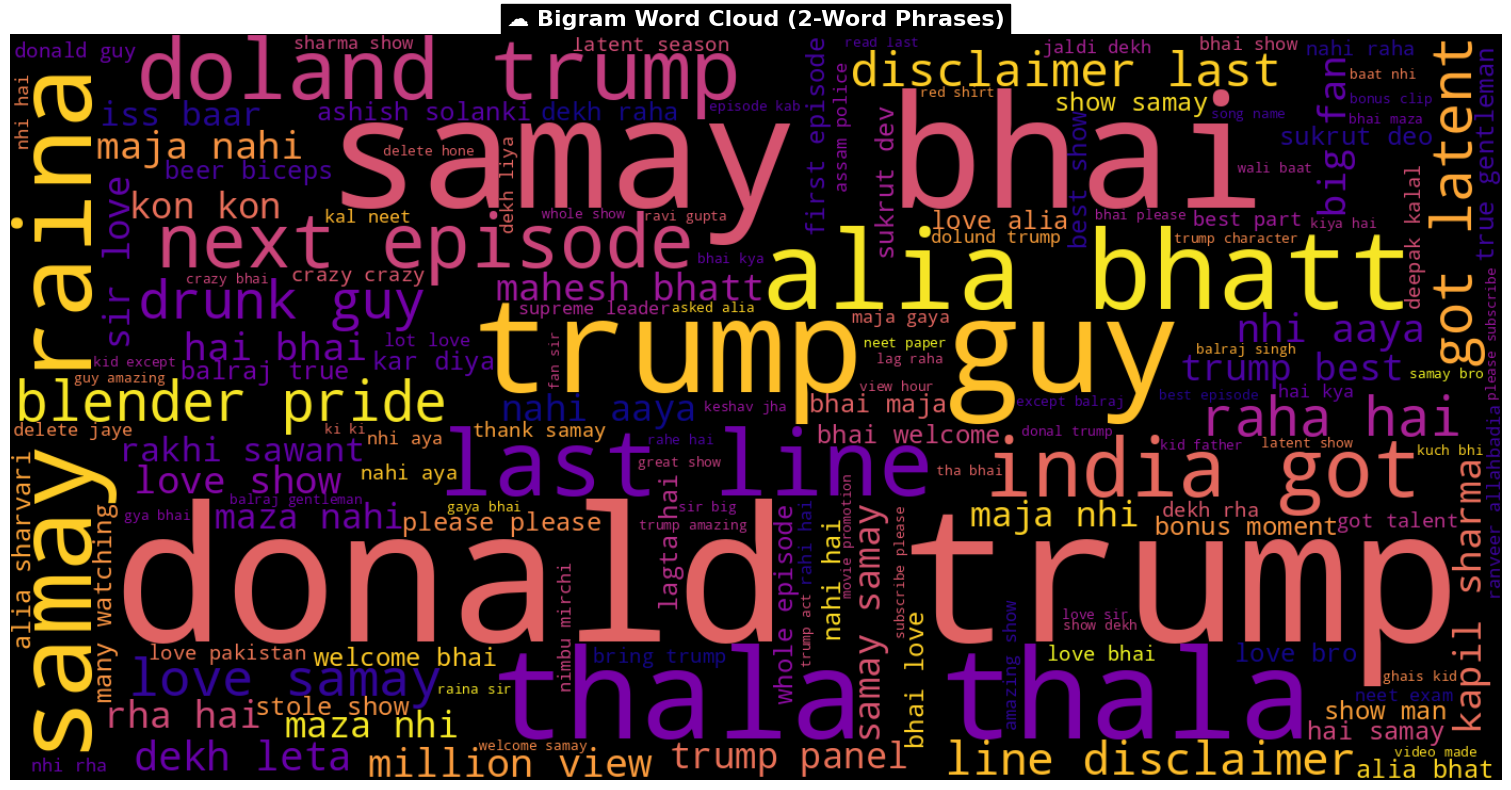

In [7]:
from wordcloud import WordCloud

# Bigram wordcloud
all_bigrams = []
for tokens in df['tokens']:
    all_bigrams.extend([' '.join(g) for g in ngrams(tokens, 2)])

bigram_freq = Counter(all_bigrams)

wc = WordCloud(width=1400, height=700, background_color='black',
               colormap='plasma', max_words=150,
               collocations=False).generate_from_frequencies(bigram_freq)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('☁️ Bigram Word Cloud (2-Word Phrases)', fontsize=16, fontweight='bold', color='white',
          backgroundcolor='black')
plt.tight_layout()
plt.savefig('bigram_wordcloud.png', dpi=150, facecolor='black')
plt.show()

⏳ Fixing misspellings...
✅ Misspellings fixed & re-tokenized!

🔍 'trump' appears in 9191 comments after fix
🔍 'donald' appears in 5472 comments after fix

📊 Total bigrams       : 197619
✅ Meaningful bigrams  : 185180

🔥 TOP 20 MEANINGFUL BIGRAMS:
   donald trump                   → 4511
   samay bhai                     → 2544
   trump guy                      → 1711
   alia bhatt                     → 1170
   samay raina                    → 1102
   last line                      → 814
   next episode                   → 532
   blender pride                  → 518
   raha hai                       → 502
   love samay                     → 460
   drunk guy                      → 459
   disclaimer last                → 384
   line disclaimer                → 354
   dekh leta                      → 274
   million view                   → 265
   nhi aaya                       → 263
   hai bhai                       → 252
   love show                      → 251
   maja nahi                

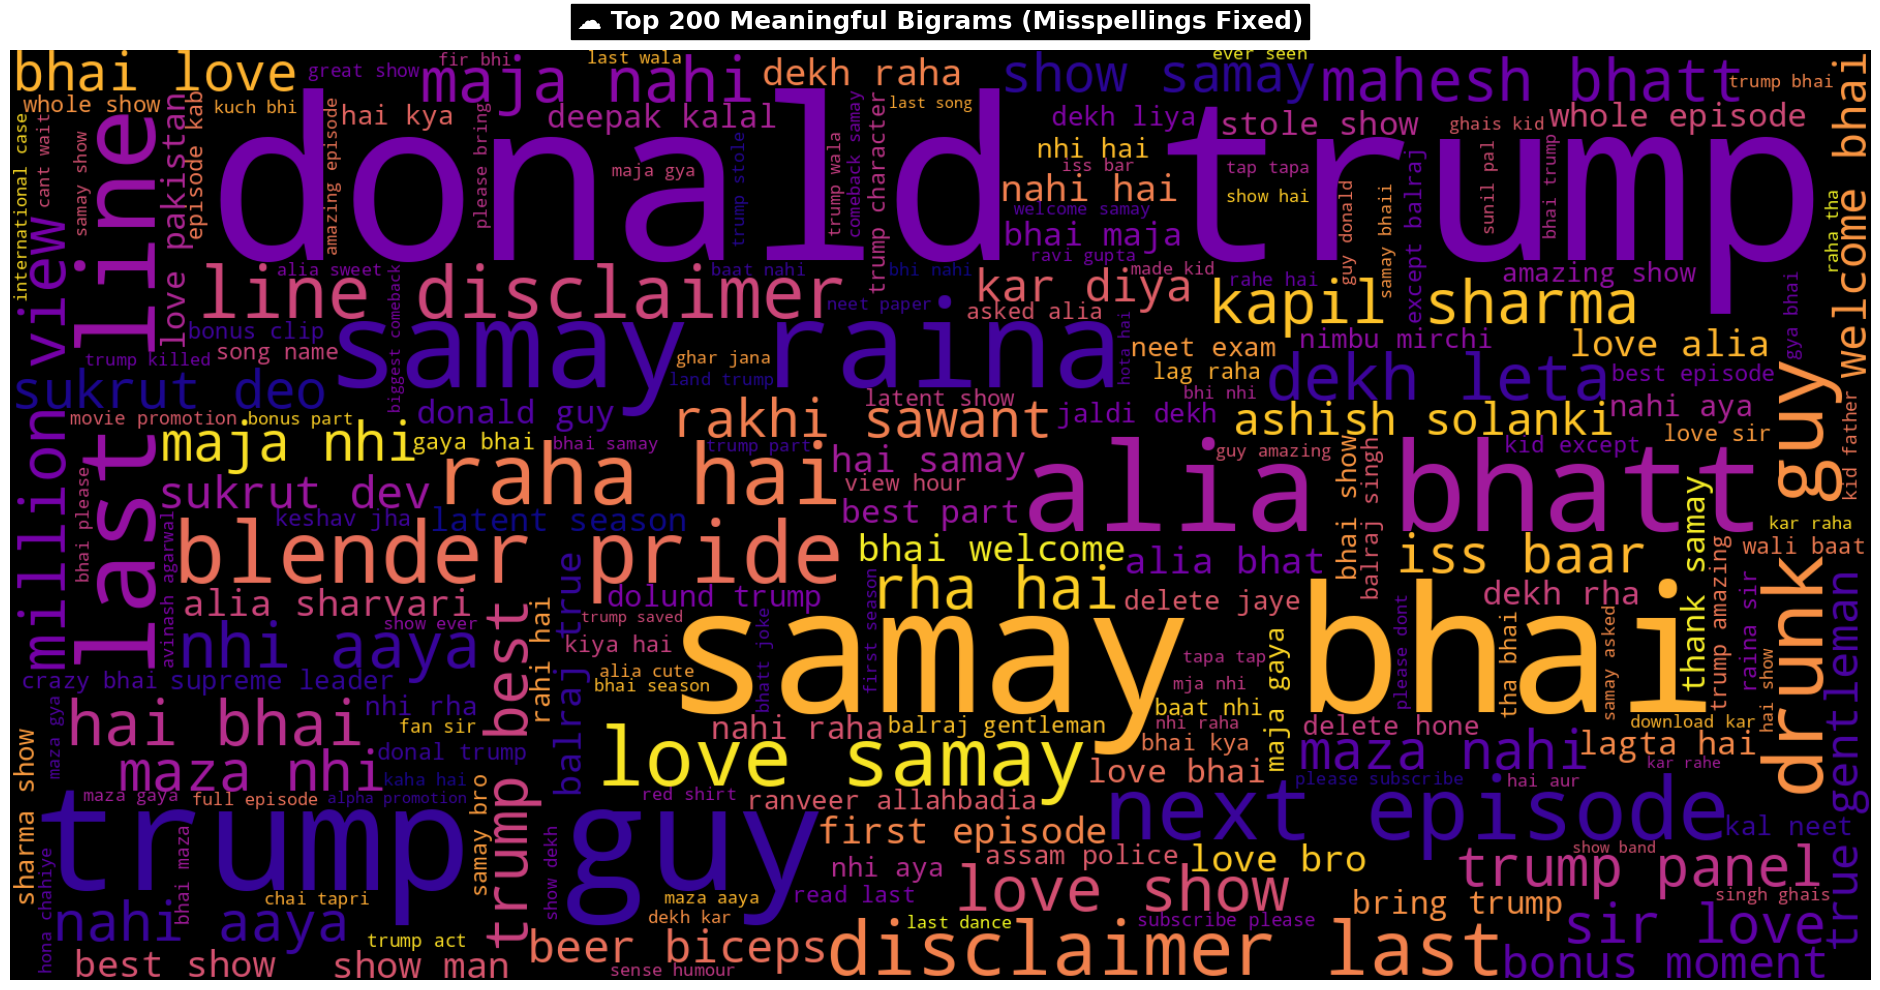

✅ Fixed Bigram Word Cloud saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All downloaded!


In [8]:
from wordcloud import WordCloud
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import re

# ============================================
# STEP 1 — Fix all misspellings BEFORE tokenizing
# ============================================

misspellings = {
    # Donald Trump variations
    r'\bdoland\b'   : 'donald',
    r'\btrumph\b'   : 'trump',
    r'\btramp\b'    : 'trump',
    r'\btrup\b'     : 'trump',
    r'\btrmp\b'     : 'trump',
    r'\btrumnp\b'   : 'trump',
    r'\btrupm\b'    : 'trump',
    r'\btrumb\b'    : 'trump',
    r'\btruph\b'    : 'trump',
    r'\btrumpp\b'   : 'trump',
    r'\btruimp\b'   : 'trump',
    r'\btriumph\b'  : 'trump',  # only if used as name
    r'\btrum\b'     : 'trump',

    # Add more corrections below as needed:
    # r'\bmodi\b'   : 'modi',
    # r'\binida\b'  : 'india',
}

def fix_misspellings(text):
    text = str(text).lower()
    for pattern, replacement in misspellings.items():
        text = re.sub(pattern, replacement, text)
    return text

print("⏳ Fixing misspellings...")
df['comment_fixed'] = df['comment'].apply(fix_misspellings)

# ============================================
# STEP 2 — Re-tokenize fixed comments
# ============================================
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
stop_words.update(['like','just','get','one','also','would','really','know',
                   'think','go','see','want','make','good','much','way','even',
                   'still','back','time','year','video','watch','channel','gonna',
                   'gotta','yeah','okay','hey','lol','haha','omg','guys'])

lemmatizer = WordNetLemmatizer()

def retokenize(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return tokens

df['tokens_fixed'] = df['comment_fixed'].apply(retokenize)
print("✅ Misspellings fixed & re-tokenized!")

# Verify fix worked
trump_count = sum(1 for tokens in df['tokens_fixed'] if 'trump' in tokens)
donald_count = sum(1 for tokens in df['tokens_fixed'] if 'donald' in tokens)
print(f"\n🔍 'trump' appears in {trump_count} comments after fix")
print(f"🔍 'donald' appears in {donald_count} comments after fix")

# ============================================
# STEP 3 — Generate Bigrams from FIXED tokens
# ============================================
all_bigrams = []
for tokens in df['tokens_fixed']:
    all_bigrams.extend([' '.join(g) for g in ngrams(tokens, 2)])

bigram_freq = Counter(all_bigrams)

# ============================================
# STEP 4 — Filter MEANINGFUL bigrams only
# ============================================

# Remove bigrams with these meaningless filler words
filler_words = {'said','say','saying','said','tell','told','thing','things',
                'people','person','lot','lots','put','got','getting','going',
                'come','came','coming','take','took','taking','use','used',
                'using','look','looking','looked','need','needed','needs',
                'new','old','big','small','little','many','much','every',
                'always','never','often','day','days','week','month','year'}

def is_meaningful_bigram(bigram):
    words = bigram.split()
    # Remove if either word is a filler
    if any(w in filler_words for w in words):
        return False
    # Remove if both words are same
    if words[0] == words[1]:
        return False
    # Remove very short words
    if any(len(w) < 3 for w in words):
        return False
    return True

meaningful_bigrams = {b: f for b, f in bigram_freq.items()
                      if is_meaningful_bigram(b)}

print(f"\n📊 Total bigrams       : {len(bigram_freq)}")
print(f"✅ Meaningful bigrams  : {len(meaningful_bigrams)}")

# Top 20 preview
print(f"\n🔥 TOP 20 MEANINGFUL BIGRAMS:")
for bigram, freq in Counter(meaningful_bigrams).most_common(20):
    print(f"   {bigram:<30} → {freq}")

# ============================================
# STEP 5 — Top 200 Bigram Word Cloud
# ============================================
top_200 = dict(Counter(meaningful_bigrams).most_common(200))

wc = WordCloud(
    width=1800,
    height=900,
    background_color='black',
    colormap='plasma',
    max_words=200,
    collocations=False,
    min_font_size=10,
    prefer_horizontal=0.8
).generate_from_frequencies(top_200)

plt.figure(figsize=(20, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('☁️ Top 200 Meaningful Bigrams (Misspellings Fixed)',
          fontsize=18, fontweight='bold', color='white', backgroundcolor='black', pad=15)
plt.tight_layout()
plt.savefig('bigram_wordcloud_fixed.png', dpi=180, facecolor='black',
            bbox_inches='tight')
plt.show()
print("✅ Fixed Bigram Word Cloud saved!")

# ============================================
# STEP 6 — Save to Excel too
# ============================================
import pandas as pd

bigram_df = pd.DataFrame(
    Counter(meaningful_bigrams).most_common(),
    columns=['Bigram', 'Frequency']
)
bigram_df.insert(0, 'Rank', range(1, len(bigram_df)+1))

def freq_range(f):
    if f >= 500:   return '🔥 Very High (500+)'
    elif f >= 200: return '⬆️ High (200-499)'
    elif f >= 100: return '➡️ Medium (100-199)'
    elif f >= 50:  return '⬇️ Low (50-99)'
    else:          return '❄️ Very Low (<50)'

bigram_df['Frequency Range'] = bigram_df['Frequency'].apply(freq_range)

with pd.ExcelWriter('bigram_fixed.xlsx', engine='openpyxl') as writer:
    bigram_df.to_excel(writer, sheet_name='All Bigrams', index=False)
    bigram_df.head(200).to_excel(writer, sheet_name='Top 200', index=False)
    for sheet in writer.sheets.values():
        for col in sheet.columns:
            max_len = max(len(str(cell.value or '')) for cell in col) + 4
            sheet.column_dimensions[col[0].column_letter].width = min(max_len, 50)

from google.colab import files
files.download('bigram_wordcloud_fixed.png')
files.download('bigram_fixed.xlsx')
print("✅ All downloaded!")

In [9]:
import pandas as pd
from nltk.util import ngrams
from collections import Counter

# Generate all bigrams
all_bigrams = []
for tokens in df['tokens']:
    all_bigrams.extend([' '.join(g) for g in ngrams(tokens, 2)])

# Count frequencies
bigram_freq = Counter(all_bigrams)

# Convert to DataFrame
bigram_df = pd.DataFrame(bigram_freq.most_common(), columns=['Bigram', 'Frequency'])

# Add frequency range column
def freq_range(f):
    if f >= 500:   return '🔥 Very High (500+)'
    elif f >= 200: return '⬆️ High (200-499)'
    elif f >= 100: return '➡️ Medium (100-199)'
    elif f >= 50:  return '⬇️ Low (50-99)'
    else:          return '❄️ Very Low (<50)'

bigram_df['Frequency Range'] = bigram_df['Frequency'].apply(freq_range)

# Add rank
bigram_df.insert(0, 'Rank', range(1, len(bigram_df) + 1))

# Summary sheet
summary_df = bigram_df.groupby('Frequency Range').agg(
    Total_Bigrams=('Bigram', 'count'),
    Total_Frequency=('Frequency', 'sum'),
    Top_Bigram=('Bigram', 'first')
).reset_index()

# Save to Excel with multiple sheets
with pd.ExcelWriter('bigram_analysis.xlsx', engine='openpyxl') as writer:
    bigram_df.to_excel(writer, sheet_name='All Bigrams', index=False)

    # Separate sheets per frequency range
    for freq_range_name, group in bigram_df.groupby('Frequency Range'):
        sheet_name = freq_range_name.split('(')[0].strip()[:31]  # Excel 31 char limit
        group.to_excel(writer, sheet_name=sheet_name, index=False)

    summary_df.to_excel(writer, sheet_name='Summary', index=False)

    # Auto-format column widths
    for sheet in writer.sheets.values():
        for col in sheet.columns:
            max_len = max(len(str(cell.value or '')) for cell in col) + 4
            sheet.column_dimensions[col[0].column_letter].width = min(max_len, 50)

print(f"✅ Total unique bigrams: {len(bigram_df)}")
print(f"\n📊 FREQUENCY RANGE SUMMARY:")
print(bigram_df['Frequency Range'].value_counts().to_string())
print(f"\n🔥 TOP 20 BIGRAMS:")
print(bigram_df.head(20).to_string(index=False))

# Download
from google.colab import files
files.download('bigram_analysis.xlsx')

✅ Total unique bigrams: 199516

📊 FREQUENCY RANGE SUMMARY:
Frequency Range
❄️ Very Low (<50)      199156
⬇️ Low (50-99)            220
➡️ Medium (100-199)       106
⬆️ High (200-499)          21
🔥 Very High (500+)         13

🔥 TOP 20 BIGRAMS:
 Rank          Bigram  Frequency    Frequency Range
    1    donald trump       3780 🔥 Very High (500+)
    2      samay bhai       2544 🔥 Very High (500+)
    3       trump guy       1746 🔥 Very High (500+)
    4     thala thala       1584 🔥 Very High (500+)
    5      alia bhatt       1170 🔥 Very High (500+)
    6     samay raina       1102 🔥 Very High (500+)
    7       last line        814 🔥 Very High (500+)
    8    doland trump        684 🔥 Very High (500+)
    9       india got        632 🔥 Very High (500+)
   10    next episode        532 🔥 Very High (500+)
   11   blender pride        518 🔥 Very High (500+)
   12      got latent        514 🔥 Very High (500+)
   13        raha hai        502 🔥 Very High (500+)
   14       drunk guy       

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Sentiment Analysis

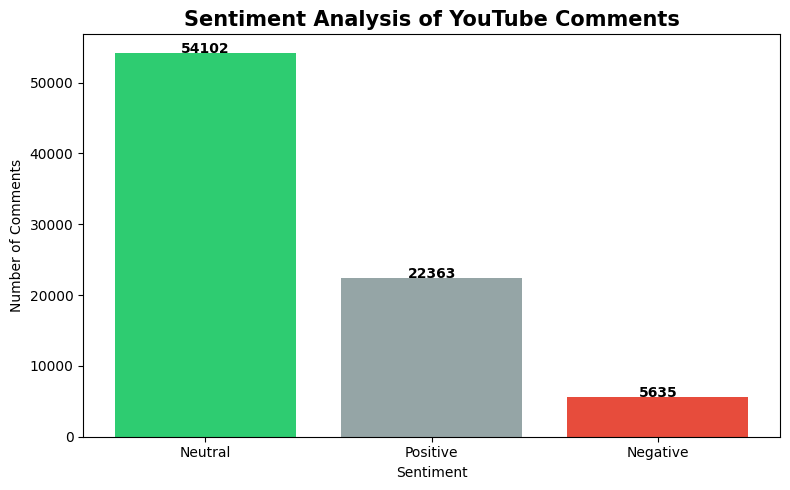

sentiment
Neutral     54102
Positive    22363
Negative     5635
Name: count, dtype: int64


In [10]:
from textblob import TextBlob
import matplotlib.pyplot as plt

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['comment'].apply(get_sentiment)

# Plot
sentiment_counts = df['sentiment'].value_counts()
colors = ['#2ecc71', '#95a5a6', '#e74c3c']

plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)
plt.title('Sentiment Analysis of YouTube Comments', fontsize=15, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
for bar, val in zip(bars, sentiment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment.png', dpi=150)
plt.show()
print(df['sentiment'].value_counts())

# Emotion Detection





In [11]:
!pip install nrclex --quiet
!pip install nltk --quiet

!pip install nrclex langdetect textblob pandas matplotlib seaborn plotly anthropic
!python -m textblob.download_corpora
import nltk
nltk.download('all')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 932.0/932.0 kB 41.5 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=8b782253593cbc9322ca40b5a22956e428393b27d253f29b9dbfc58243d1d1c8
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nlt

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data

True

In [ ]:
from nrclex import NRCLex
import matplotlib.pyplot as plt
import numpy as np

emotion_list = []

for comment in df['comment']:
    nrc = NRCLex(str(comment))
    scores = nrc.affect_frequencies  #nrc.raw_emotion_scores
    emotion_list.append({
        'fear'        : scores.get('fear', 0),
        'anger'       : scores.get('anger', 0),
        'trust'       : scores.get('trust', 0),
        'surprise'    : scores.get('surprise', 0),
        'sadness'     : scores.get('sadness', 0),
        'disgust'     : scores.get('disgust', 0),
        'joy'         : scores.get('joy', 0),
        'anticipation': scores.get('anticipation', 0),
    })

emotion_df = pd.DataFrame(emotion_list)
df = pd.concat([df, emotion_df], axis=1)
df['dominant_emotion'] = emotion_df.idxmax(axis=1)

# Fix: comments with all zero emotions
df.loc[emotion_df.sum(axis=1) == 0, 'dominant_emotion'] = 'neutral'

# Plot 1 — Total emotion scores
emotion_totals = emotion_df.sum().sort_values(ascending=False)
colors = ['#f1c40f','#e74c3c','#2ecc71','#3498db','#9b59b6','#1abc9c','#e67e22','#95a5a6']

plt.figure(figsize=(12, 5))
bars = plt.bar(emotion_totals.index, emotion_totals.values, color=colors)
plt.title('😤 Emotion Detection Across All Comments', fontsize=14, fontweight='bold')
plt.ylabel('Total Emotion Score')
for bar, val in zip(bars, emotion_totals.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(val)), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('emotions.png', dpi=150)
plt.show()

# Plot 2 — Dominant emotion per comment
plt.figure(figsize=(10, 5))
dom = df['dominant_emotion'].value_counts()
plt.pie(dom.values, labels=dom.index, autopct='%1.1f%%',
        colors=plt.cm.Set3.colors, startangle=90)
plt.title('🎯 Dominant Emotion Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dominant_emotion.png', dpi=150)
plt.show()

print("\n🎯 DOMINANT EMOTIONS:")
print(df['dominant_emotion'].value_counts())

# **More anlysis you can do below:**


1.   Comment Length Analysis
2.   Like Count vs Sentiment
3.   Comment Intent Classification
4.   Language Detection

